In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point, box
import io
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, \
precision_score, recall_score, f1_score
import joblib
from google.colab import files
import seaborn as sns
!pip install dbfread

grid = gpd.read_file('/content/full_df_1210-1.xlsx')

발생 0건 시군: ['가평군', '양평군', '연천군']
발생 시군 수: 28
✅ 최종 훈련 데이터 크기: (113832, 37)
✅ 최종 테스트 데이터 크기: (17496, 37)
Train 포함 시군 수: 25
Test 포함 시군 수 : 6

🚫 Test에 발생 0건 시군 포함 여부: set()

Train 발생 비율:
label
0    0.998428
1    0.001572
Name: proportion, dtype: float64

Test 발생 비율:
label
0    0.993827
1    0.006173
Name: proportion, dtype: float64

====================== Logistic Regression 테스트 결과 ======================
Accuracy : 0.906092821216278
Precision: 0.0471976401179941
Recall   : 0.7407407407407407
F1-score : 0.08874098724348309
ROC-AUC  : 0.9001573030357249
PR-AUC   : 0.10810523976339509

혼동행렬:
       예측 0  예측 1
실제 0  15773  1615
실제 1     28    80


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from fon

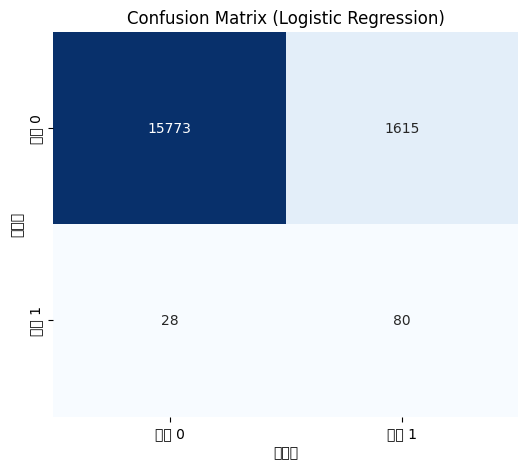


📌 Logistic Regression 변수 영향력 (절대값 기준):
             feature      coef  abs_coef
7             d_road -1.737074  1.737074
30         sw_rep_rt  1.086959  1.086959
31         sw_rep_rn -0.744800  0.744800
29          rain_sum -0.611750  0.611750
16         elevation -0.496073  0.496073
13          d_subway -0.405160  0.405160
18         bld_count  0.394966  0.394966
34           sw_dens -0.311159  0.311159
4   floor_area_ratio  0.306125  0.306125
8            rd_dens  0.285667  0.285667
25          cnt_Live -0.277380  0.277380
21           avg_age  0.235758  0.235758
23          cnt_Comm  0.212836  0.212836
28          uw_level -0.154330  0.154330
36           pp_conc  0.145028  0.145028


In [4]:
# ================================
# Logistic Regression 모델
# ================================

from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix
)

features = ['building_count', 'population',
       'building_coverage_ratio', 'building_height', 'floor_area_ratio',
       'litho_risk', 'd_fault', 'd_road', 'rd_dens',
       'ln_rd_load', 'ln_rd_prox', 'd_tunnel', 'tun_area', 'd_subway',
       'd_rail', 'rl_dens', 'elevation', 'slope_deg', 'bld_count', 'tot_area',
       'avg_flr', 'avg_age', 'avg_und', 'cnt_Comm', 'cnt_Fact'
       , 'cnt_Live', 'cnt_Water', 'soil_scr', 'uw_level'
       , 'rain_sum', 'sw_rep_rt', 'sw_rep_rn', 'sw_drg',
       'sw_old_rt', 'sw_dens', 'rn_pp_dens', 'pp_conc']

df = grid[features].apply(pd.to_numeric, errors="coerce")

X = df[features]
y = grid["label"]

city_event = grid.groupby("SGG_NM")["label"].sum().reset_index()
city_event.columns = ["city", "event_count"]

# 🔴 [추가] 발생건수 0인 시군 제외
zero_cities = city_event[city_event["event_count"] == 0]["city"].tolist()

# 발생 있는 시군 (Train/Test 대상)
nonzero_cities = city_event[city_event["event_count"] > 0]["city"].tolist()

print("발생 0건 시군:", zero_cities)
print("발생 시군 수:", len(nonzero_cities))

train_cities, test_cities = train_test_split(
    nonzero_cities,
    test_size=0.2,     # ✅ 시군 기준 8:2
    random_state=42
)

# ✅ Train = (발생 시군 중 80%) + (발생 0건 시군 전체)
train_idx = grid["SGG_NM"].isin(train_cities + zero_cities)

# ✅ Test = 발생 시군 중 20%만
test_idx = grid["SGG_NM"].isin(test_cities)

X_train = grid.loc[train_idx, features].apply(pd.to_numeric, errors="coerce")
y_train = grid.loc[train_idx, "label"].astype(int)

X_test  = grid.loc[test_idx, features].apply(pd.to_numeric, errors="coerce")
y_test  = grid.loc[test_idx, "label"].astype(int)

print("✅ 최종 훈련 데이터 크기:", X_train.shape)
print("✅ 최종 테스트 데이터 크기:", X_test.shape)

print("Train 포함 시군 수:", grid.loc[X_train.index, "SGG_NM"].nunique())
print("Test 포함 시군 수 :", grid.loc[X_test.index, "SGG_NM"].nunique())

print("\n🚫 Test에 발생 0건 시군 포함 여부:",
      set(test_cities) & set(zero_cities))

print("\nTrain 발생 비율:")
print(y_train.value_counts(normalize=True))

print("\nTest 발생 비율:")
print(y_test.value_counts(normalize=True))

# ================================
# 1) Pipeline 구성
#    - Logistic은 스케일링 필수
# ================================

logi_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logi", LogisticRegression(
        penalty="l2",
        C=0.01,
        solver="liblinear",
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ))
])

# ================================
# 2) 모델 학습
# ================================

logi_model.fit(X_train, y_train)

# ================================
# 3) Threshold 적용 예측
# ================================

threshold = 0.90   # BRF와 동일 기준 비교

y_prob = logi_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= threshold).astype(int)

# ================================
# 4) 성능 평가
# ================================

pr_auc = average_precision_score(y_test, y_prob)

print("\n====================== Logistic Regression 테스트 결과 ======================")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
print("F1-score :", f1_score(y_test, y_pred, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))
print("PR-AUC   :", pr_auc)

# ================================
# 5) Confusion Matrix
# ================================

cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=["실제 0", "실제 1"],
    columns=["예측 0", "예측 1"]
)

print("\n혼동행렬:")
print(cm_df)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix (Logistic Regression)")
plt.xlabel("예측값")
plt.ylabel("실제값")
plt.show()

# ================================
# Logistic Regression 계수 확인
# ================================

coef = logi_model.named_steps["logi"].coef_[0]

coef_df = pd.DataFrame({
    "feature": features,
    "coef": coef,
    "abs_coef": np.abs(coef)
}).sort_values("abs_coef", ascending=False)

print("\n📌 Logistic Regression 변수 영향력 (절대값 기준):")
print(coef_df.head(15))

In [5]:
# ================================
# 6) 모델 저장
# ================================

import joblib
from datetime import datetime

save_obj = {
    "model": logi_model,      # Pipeline 자체
    "features": features,     # 컬럼 순서 매우 중요
    "threshold": threshold,   # 예측 기준값
    "model_name": "LogisticRegression_sinkhole_risk",
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
}

joblib.dump(save_obj, "sinkhole_logi_model.pkl")

print("\n✅ 모델 저장 완료: sinkhole_logi_model.pkl")


✅ 모델 저장 완료: sinkhole_logi_model.pkl
